In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

class DataCleaner:
    """
    Comprehensive data cleaning and preparation module
    """
    
    def __init__(self, df):
        self.df = df.copy()
        self.report = {}
        self.encoders = {}
        
    def handle_missing_values(self, strategy='mean'):
        """Handle missing values"""
        print("🔍 Handling missing values...")
        
        initial_missing = self.df.isnull().sum()
        self.report['missing_values_before'] = initial_missing
        
        # Numeric columns - fill with mean
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if self.df[col].isnull().sum() > 0:
                self.df[col].fillna(self.df[col].mean(), inplace=True)
        
        # Categorical columns - fill with mode
        categorical_cols = self.df.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            if self.df[col].isnull().sum() > 0:
                self.df[col].fillna(self.df[col].mode()[0], inplace=True)
        
        final_missing = self.df.isnull().sum()
        self.report['missing_values_after'] = final_missing
        
        print(f"✅ Missing values handled")
        print(f"   - Rows with missing data: {initial_missing.sum()} → {final_missing.sum()}")
        
        return self
    
    def remove_duplicates(self):
        """Remove duplicate records"""
        print("🔍 Removing duplicates...")
        
        initial_rows = len(self.df)
        self.df.drop_duplicates(subset=['transaction_id'], inplace=True)
        final_rows = len(self.df)
        
        self.report['duplicates_removed'] = initial_rows - final_rows
        
        print(f"✅ Duplicates removed: {initial_rows - final_rows} records")
        
        return self
    
    def handle_outliers(self, method='iqr', threshold=1.5):
        """Handle outliers using IQR method"""
        print("🔍 Handling outliers...")
        
        numeric_cols = ['transaction_amount']
        outliers_count = 0
        
        for col in numeric_cols:
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            
            # Cap outliers instead of removing
            before = self.df[col].shape[0]
            self.df[col] = self.df[col].clip(lower_bound, upper_bound)
            
            outlier_rows = (self.df[col] < lower_bound) | (self.df[col] > upper_bound)
            outliers_count += outlier_rows.sum()
        
        self.report['outliers_handled'] = outliers_count
        
        print(f"✅ Outliers handled: {outliers_count} values capped")
        
        return self
    
    def encode_categorical(self):
        """Encode categorical variables"""
        print("🔍 Encoding categorical variables...")
        
        categorical_cols = self.df.select_dtypes(include=['object']).columns
        categorical_cols = [col for col in categorical_cols if col not in ['transaction_id', 'customer_id', 'merchant_id']]
        
        for col in categorical_cols:
            encoder = LabelEncoder()
            self.df[col + '_encoded'] = encoder.fit_transform(self.df[col])
            self.encoders[col] = encoder
        
        print(f"✅ Encoded {len(categorical_cols)} categorical columns")
        
        return self
    
    def normalize_features(self):
        """Normalize numerical features"""
        print("🔍 Normalizing features...")
        
        numeric_cols = ['transaction_amount']
        scaler = StandardScaler()
        self.df[numeric_cols] = scaler.fit_transform(self.df[numeric_cols])
        
        self.report['scaler'] = scaler
        
        print(f"✅ Features normalized")
        
        return self
    
    def generate_report(self):
        """Generate data quality report"""
        print("\n" + "="*60)
        print("📊 DATA QUALITY REPORT")
        print("="*60)
        print(f"Total Records: {len(self.df):,}")
        print(f"Duplicates Removed: {self.report.get('duplicates_removed', 0)}")
        print(f"Missing Values Handled: {self.report.get('missing_values_before', {}).sum() if 'missing_values_before' in self.report else 0}")
        print(f"Outliers Handled: {self.report.get('outliers_handled', 0)}")
        print(f"Fraud Cases: {self.df['is_fraud'].sum():,} ({self.df['is_fraud'].mean()*100:.2f}%)")
        print("="*60)
        
        return self.report
    
    def get_cleaned_data(self):
        """Return cleaned dataframe"""
        return self.df

In [2]:
import os

print(os.getcwd())

C:\Users\Dell\FraudShield AI


In [3]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'dashboard', 'data', 'day_01.ipynb', 'day_02.ipynb', 'FraudShield AI.docx', 'images', 'models', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'src']


In [4]:
import src.data_cleaner

print(src.data_cleaner.__file__)

C:\Users\Dell\FraudShield AI\src\data_cleaner.py


In [5]:
with open("src/data_cleaner.py", "r", encoding="utf-8") as f:
    print(f.read())

import pandas as pd
import numpy as np


class DataCleaner:

    def __init__(self, df):
        self.df = df.copy()

    def handle_missing_values(self):

        print("Handling missing values...")

        numeric_cols = self.df.select_dtypes(
            include=[np.number]
        ).columns

        for col in numeric_cols:
            self.df[col] = self.df[col].fillna(
                self.df[col].median()
            )

        print("Done")

        return self

    def get_cleaned_data(self):
        return self.df


In [6]:
import importlib
import src.data_cleaner

importlib.reload(src.data_cleaner)

from src.data_cleaner import DataCleaner

print([m for m in dir(DataCleaner) if not m.startswith("__")])

['encode_categorical', 'generate_report', 'get_cleaned_data', 'handle_missing_values', 'handle_outliers', 'normalize_features', 'remove_duplicates']


In [7]:
cleaner = DataCleaner(df_raw)

cleaner.handle_missing_values() \
       .remove_duplicates() \
       .handle_outliers() \
       .generate_report()

df_clean = cleaner.get_cleaned_data()

NameError: name 'df_raw' is not defined

In [8]:
import pandas as pd

df_raw = pd.read_csv(
    "data/raw_transactions.csv",
    parse_dates=["timestamp"]
)

print(df_raw.shape)

(250000, 15)


In [9]:
from src.data_cleaner import DataCleaner

cleaner = DataCleaner(df_raw)

cleaner.handle_missing_values() \
       .remove_duplicates() \
       .handle_outliers() \
       .generate_report()

df_clean = cleaner.get_cleaned_data()

🔍 Handling missing values...
✅ Missing values handled
Missing values: 250 → 0
🔍 Removing duplicates...
✅ Duplicates removed: 0 records
🔍 Handling outliers...
✅ Outliers handled: 13119 values capped

📊 DATA QUALITY REPORT
Total Records: 250,000
Duplicates Removed: 0
Missing Values: 250 → 0
Outliers Handled: 13119
Fraud Cases: 10,000
Fraud Percentage: 4.00%


In [10]:
df_clean = cleaner.get_cleaned_data()

df_clean.to_csv(
    "data/processed/clean_transactions.csv",
    index=False
)

print("✅ Clean dataset saved successfully")

✅ Clean dataset saved successfully


In [11]:
from src.data_loader import load_and_clean_data

df_clean, cleaner = load_and_clean_data(
    "data/raw_transactions.csv"
)

df_clean.head()

📥 LOADING AND CLEANING DATA

📂 Loading data from data/raw_transactions.csv...
✅ Loaded 250,000 records with 15 columns
🔍 Handling missing values...
✅ Missing values handled
Missing values: 250 → 0
🔍 Removing duplicates...
✅ Duplicates removed: 0 records
🔍 Handling outliers...
✅ Outliers handled: 13119 values capped

📊 DATA QUALITY REPORT
Total Records: 250,000
Duplicates Removed: 0
Missing Values: 250 → 0
Outliers Handled: 13119
Fraud Cases: 10,000
Fraud Percentage: 4.00%


,transaction_id,timestamp,customer_id,merchant_id,transaction_amount,merchant_category,card_type,transaction_type,country,device_type,is_fraud,transaction_hour,transaction_day,transaction_month,transaction_day_of_week
0,TXN_0000001,2024-10-16 03:01:00,CUST_010607,MERCH_09995,93.853618,Airlines,Credit,Online,USA,Tablet,0,3.0,16,10,2
1,TXN_0000002,2023-10-09 07:14:00,CUST_044501,MERCH_06467,602.024286,Clothing,Credit,Offline,Brazil,POS,0,7.0,9,10,0
2,TXN_0000003,2023-05-23 23:06:00,CUST_027157,MERCH_05502,263.349139,Clothing,Debit,Online,Australia,Desktop,0,23.0,23,5,1
3,TXN_0000004,2024-11-23 23:57:00,CUST_004958,MERCH_02380,182.588511,Pharmacy,Debit,Mobile,USA,Tablet,0,23.0,23,11,5
4,TXN_0000005,2024-07-12 02:37:00,CUST_048904,MERCH_05684,33.924974,Entertainment,Credit,Mobile,France,POS,0,2.0,12,7,4


In [34]:
import os

os.makedirs(
    "reports",
    exist_ok=True
)

print("✅ Reports folder ready")

✅ Reports folder ready


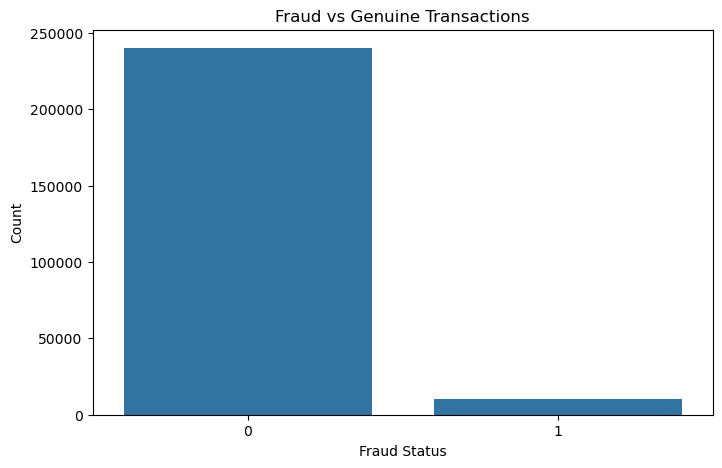

is_fraud
0    240000
1     10000
Name: count, dtype: int64


In [35]:
from src.eda import FraudEDA

eda = FraudEDA(df_clean)

eda.fraud_distribution()

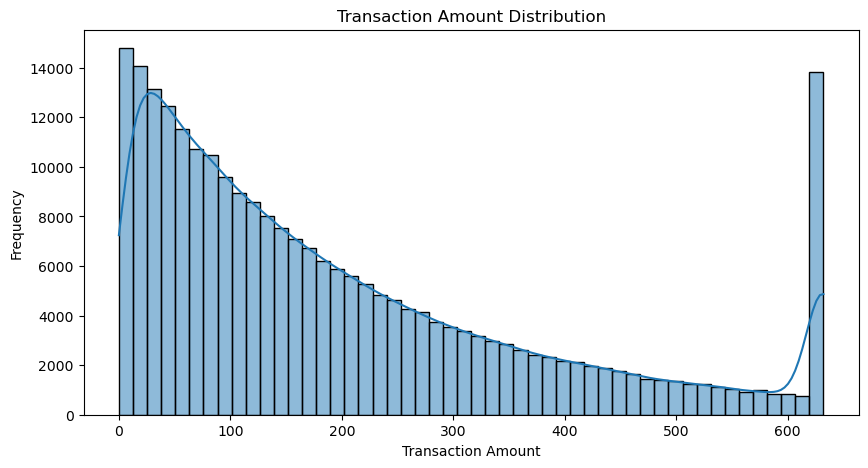

count    250000.000000
mean        198.552772
std         176.610991
min           0.000460
25%          59.248622
50%         143.336535
75%         288.367181
max         632.045021
Name: transaction_amount, dtype: float64


In [36]:
import importlib
import src.eda

importlib.reload(src.eda)

from src.eda import FraudEDA

eda = FraudEDA(df_clean)

eda.transaction_amount_distribution()

In [37]:
import importlib
import src.eda

importlib.reload(src.eda)

from src.eda import FraudEDA

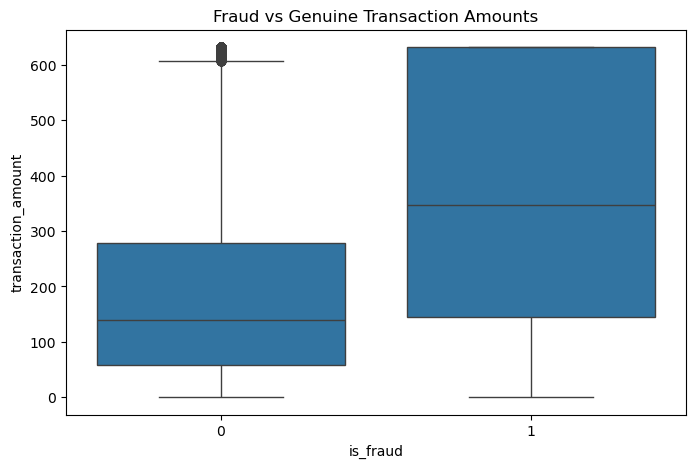

In [38]:
eda = FraudEDA(df_clean)

eda.fraud_amount_comparison()

In [23]:
import importlib
import src.eda

importlib.reload(src.eda)

from src.eda import FraudEDA

eda = FraudEDA(df_clean)

In [39]:
print([m for m in dir(FraudEDA) if not m.startswith("__")])

['correlation_heatmap', 'fraud_amount_comparison', 'fraud_by_country', 'fraud_by_hour', 'fraud_by_transaction_type', 'fraud_distribution', 'transaction_amount_distribution']


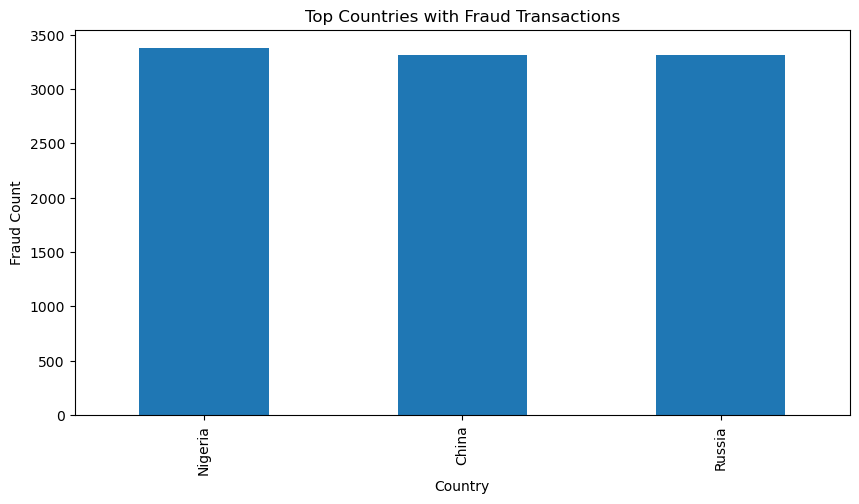

country
Nigeria    3375
China      3315
Russia     3310
Name: count, dtype: int64


In [40]:
eda.fraud_by_country()

In [27]:
import importlib
import src.eda

importlib.reload(src.eda)

from src.eda import FraudEDA

eda = FraudEDA(df_clean)

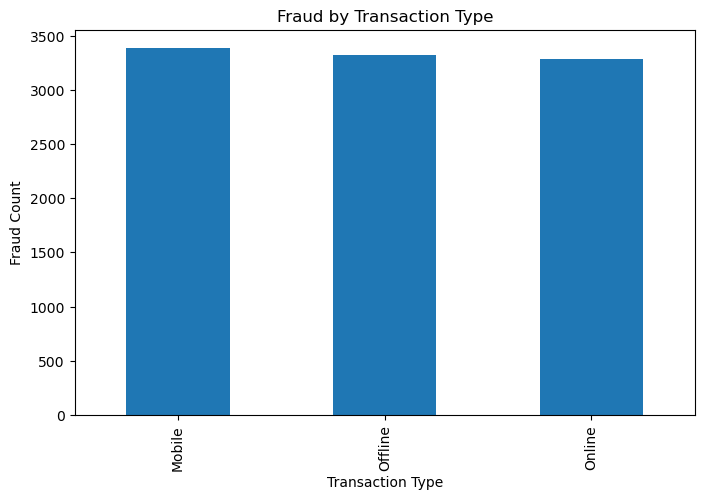

transaction_type
Mobile     3386
Offline    3324
Online     3290
Name: count, dtype: int64


In [41]:
eda.fraud_by_transaction_type()

In [42]:
import importlib
import src.eda

importlib.reload(src.eda)

from src.eda import FraudEDA

eda = FraudEDA(df_clean)

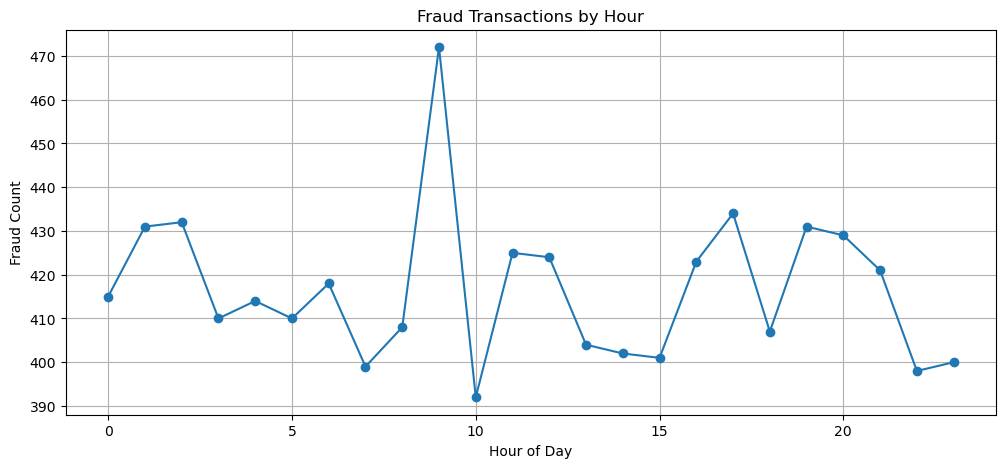

transaction_hour
0.0     415
1.0     431
2.0     432
3.0     410
4.0     414
5.0     410
6.0     418
7.0     399
8.0     408
9.0     472
10.0    392
11.0    425
12.0    424
13.0    404
14.0    402
15.0    401
16.0    423
17.0    434
18.0    407
19.0    431
20.0    429
21.0    421
22.0    398
23.0    400
Name: count, dtype: int64


In [43]:
eda.fraud_by_hour()

In [44]:
import importlib
import src.eda

importlib.reload(src.eda)

from src.eda import FraudEDA

eda = FraudEDA(df_clean)

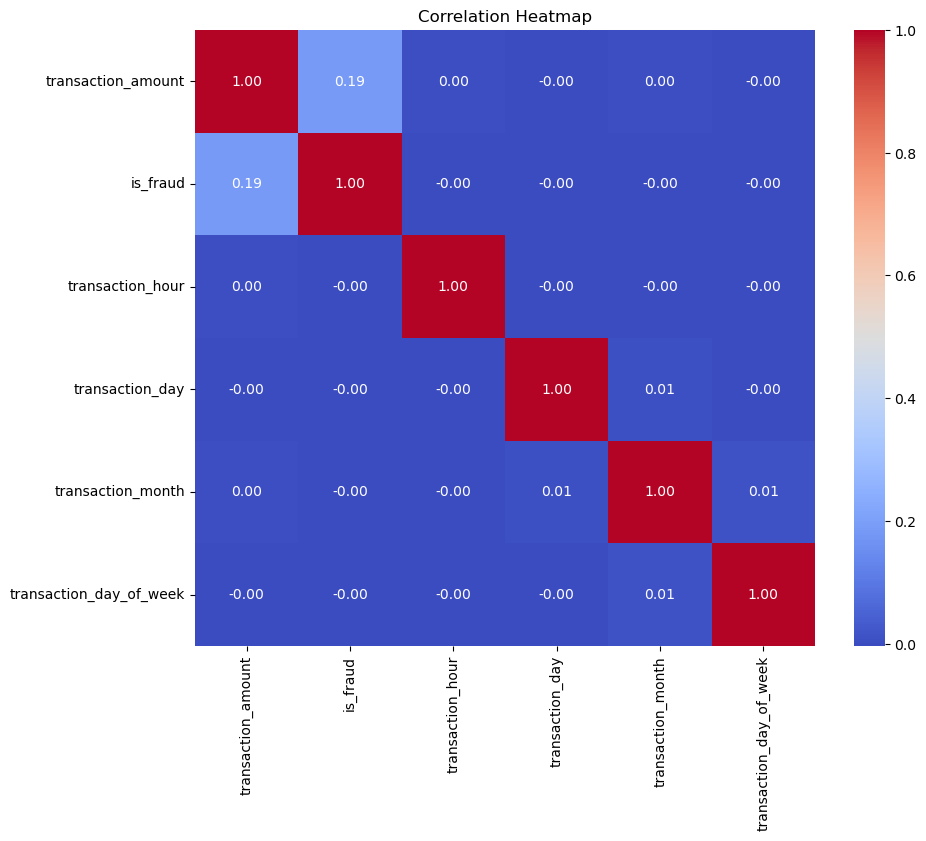

In [45]:
eda.correlation_heatmap()

In [46]:
df_clean.to_csv(
    "data/processed/clean_transactions.csv",
    index=False
)

print("✅ Clean dataset saved")

✅ Clean dataset saved


In [47]:
import os

print(os.listdir("reports"))

['02_transaction_amount_distribution.png', '03_fraud_amount_comparison.png', '04_fraud_by_country.png', '05_fraud_by_transaction_type.png', '06_fraud_by_hour.png', '07_correlation_heatmap.png']
